# U-Phase: Die Daten verstehen (Explorative Datenanalyse)

Im Projekt **AirAlert** wollen wir urbane Luftqualitätsdaten so übersetzen, dass daraus ein verständliches Risikosignal für nicht-technische Nutzer entsteht. Die U-Phase ist dafür das Fundament: Bevor ein Modell trainiert wird, müssen Datenquellen, Datenstruktur, Datenqualität, erste Muster und notwendige Vorbereitungsschritte verstanden werden.

Diese U-Phase orientiert sich bewusst am Aufbau des Beispielprojekts **Degrees of No Return**:

1. Wahl und Beschreibung der Datensätze
2. Erste Grafiken und Tabellen
3. Detektivarbeit: Datenqualität und fehlende Werte
4. Vorbereitung auf Machine Learning
5. Zusammenfassung und Interpretation im Projektkontext

Der Unterschied liegt im Kontext: Statt CO2, Temperatur, Meeresspiegel und Topografie untersucht AirAlert **Luftschadstoffe, Wetterbedingungen und Stadtstruktur**.

## Aufgabe 1: Wahl und Beschreibung der Datensätze

Die Forschungsfrage von AirAlert lautet:

**Wie können Luftqualitäts-, Wetter- und Stadtstruktur-Daten kombiniert werden, um urbane Luftqualitätsrisiken verständlich vorherzusagen?**

Dafür nutzt AirAlert drei Datenebenen. In der präsentationssicheren Version werden diese Daten deterministisch in `src/data_factory.py` erzeugt. Das ist eine bewusste technische Entscheidung: Die App läuft dadurch ohne API-Keys, ohne kaputte Downloads und ohne externe Rate-Limits stabil in PyCharm und Streamlit Cloud.

### 1. Luftqualitätsdaten

**Einfach erklärt:** Diese Daten beschreiben, wie stark die Luft durch wichtige Schadstoffe belastet ist. Werte wie PM2.5, PM10, NO2 und O3 sind für Laien schwer einzuordnen. AirAlert übersetzt diese technischen Messwerte deshalb in eine verständliche Risikoklasse.

- **Spalten:** `pm25`, `pm10`, `no2`, `o3`, `aqi_score`, `risk_level`
- **Rolle im Projekt:** Grundlage für die Risikoeinschätzung
- **Zielvariable:** `risk_level` mit den Klassen `Low`, `Medium`, `High`
- **Realistische Datenquelle für spätere Version:** OpenAQ oder lokale Messstationen
- **Limitation:** Die aktuelle Version nutzt kontrollierte Demodaten, keine offiziellen Live-Messwerte.

### 2. Wetterdaten

**Einfach erklärt:** Wetter beeinflusst, ob Schadstoffe in der Luft bleiben oder verteilt werden. Wind kann Schadstoffe verdünnen, Temperatur und Jahreszeit können die Bildung bestimmter Schadstoffe beeinflussen.

- **Spalten:** `temperature_c`, `humidity_pct`, `wind_kmh`, `month`
- **Rolle im Projekt:** Kontext für Schadstoffbelastung
- **Realistische Datenquelle für spätere Version:** Open-Meteo historische Wetterdaten
- **Limitation:** Mikroklima auf Straßenebene wird nicht modelliert.

### 3. Stadtstruktur-Daten

**Einfach erklärt:** Städte unterscheiden sich in Verkehr, Industrie, Grünflächen und Bevölkerungsgröße. Diese Faktoren verändern die Grundbelastung und helfen dem Modell, Städte nicht als identisch zu behandeln.

- **Spalten:** `city`, `country`, `latitude`, `longitude`, `population_m`, `traffic_index`, `green_space_index`, `industrial_index`
- **Rolle im Projekt:** strukturelle Erklärung der Stadtunterschiede
- **Realistische Datenquelle für spätere Version:** GeoNames, World Cities, kommunale Open-Data-Portale
- **Limitation:** Indizes sind vereinfachte Proxy-Werte.

## Aufgabe 2: Ein Bild sagt mehr als tausend Zahlen - erste Grafiken

Wie im Beispielprojekt werden zuerst Werkzeuge importiert, Daten geladen und dann erste Tabellen und Grafiken erstellt. Diese Grafiken helfen, Muster und mögliche Probleme früh zu erkennen.

In [39]:
# ============================================================
# Bibliotheken importieren und Umgebung prüfen
# Diese Zelle ist absichtlich robust:
# Falls PyCharm versehentlich einen falschen Kernel nutzt,
# versucht sie fehlende Standardpakete nachzuinstallieren.
# Empfohlen bleibt aber der Kernel: AirAlert (Python 3.13)
# ============================================================

from pathlib import Path
import importlib.util
import os
import subprocess
import sys

# Matplotlib soll keinen gesperrten User-Cache unter C:\Users\aliya\.matplotlib nutzen.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "plotly": "plotly",
}

missing = [pip_name for module_name, pip_name in required_packages.items() if importlib.util.find_spec(module_name) is None]
if missing:
    print("Fehlende Pakete werden installiert:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

print("Python:", sys.executable)
print("pandas:", pd.__version__)

Python: C:\Users\aliya\AppData\Local\Programs\Python\Python314\python.exe
pandas: 3.0.3


### Vorbereitung: AirAlert-Daten laden

Die Daten werden nicht aus externen Dateien geladen, sondern aus der Datenfabrik der App. Dadurch entspricht die Analyse exakt dem Datensatz, den auch die Streamlit-App verwendet.

In [35]:
# ============================================================
# Projektpfad dynamisch bestimmen
# Das Notebook liegt im Ordner notebooks/.
# Der Projektroot ist daher normalerweise eine Ebene darüber.
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_factory import CITY_PROFILES, build_airalert_dataset, estimate_aqi_score

df = build_airalert_dataset()

print(f"Projektroot: {PROJECT_ROOT}")
print(f"Zeilen: {len(df)}")
print(f"Spalten: {len(df.columns)}")
print(f"Städte: {df['city'].nunique()}")
print(f"Zeitraum: {df['date'].min().date()} bis {df['date'].max().date()}")

df.head()

Projektroot: C:\Users\aliya\Documents\Codex\2026-05-15\files-mentioned-by-the-user-python\airalert_app - CopyPresentReady\airalert_app
Zeilen: 576
Spalten: 20
Städte: 8
Zeitraum: 2020-01-01 bis 2025-12-01


,date,year,month,city,country,latitude,longitude,population_m,traffic_index,green_space_index,industrial_index,temperature_c,humidity_pct,wind_kmh,pm25,pm10,no2,o3,aqi_score,risk_level
0,2020-01-01,2020,1,Berlin,Germany,52.52,13.405,3.76,58.0,46.0,38.0,10.4,63.8,16.2,26.1,26.1,28.7,29.7,59.2,Medium
1,2020-02-01,2020,2,Berlin,Germany,52.52,13.405,3.76,58.0,46.0,38.0,14.8,63.9,11.4,27.1,39.3,36.1,38.7,73.8,Medium
2,2020-03-01,2020,3,Berlin,Germany,52.52,13.405,3.76,58.0,46.0,38.0,20.2,49.0,15.0,11.7,32.1,31.1,35.4,42.1,Low
3,2020-04-01,2020,4,Berlin,Germany,52.52,13.405,3.76,58.0,46.0,38.0,19.6,58.1,13.5,13.7,26.8,34.2,38.3,46.2,Medium
4,2020-05-01,2020,5,Berlin,Germany,52.52,13.405,3.76,58.0,46.0,38.0,20.1,55.5,20.3,12.0,24.9,26.6,40.3,35.9,Low


### 2.1 Überblick: Struktur des AirAlert-Datensatzes

Diese Tabelle fasst die wichtigsten Eigenschaften des Datensatzes zusammen. Sie erfüllt dieselbe Funktion wie die ersten Datenchecks im Beispielprojekt: Wir prüfen, ob der Datensatz groß genug, vollständig und strukturell passend ist.

In [40]:
dataset_overview = pd.DataFrame(
    {
        "Eigenschaft": [
            "Anzahl Zeilen",
            "Anzahl Spalten",
            "Anzahl Städte",
            "Startdatum",
            "Enddatum",
            "Zielvariable",
            "Einheit einer Zeile",
        ],
        "Wert": [
            len(df),
            len(df.columns),
            df["city"].nunique(),
            df["date"].min().strftime("%Y-%m-%d"),
            df["date"].max().strftime("%Y-%m-%d"),
            "risk_level",
            "eine Stadt in einem Monat",
        ],
    }
)
dataset_overview

,Eigenschaft,Wert
0,Anzahl Zeilen,576
1,Anzahl Spalten,20
2,Anzahl Städte,8
3,Startdatum,2020-01-01
4,Enddatum,2025-12-01
5,Zielvariable,risk_level
6,Einheit einer Zeile,eine Stadt in einem Monat


### 2.2 Luftbelastung nach Stadt

Die erste inhaltliche Grafik zeigt, welche Städte im Datensatz im Durchschnitt höhere AQI-ähnliche Werte haben. Das entspricht im Beispielprojekt der ersten Trendvisualisierung: Die Rohdaten werden sichtbar und interpretierbar gemacht.

In [21]:
city_summary = (
    df.groupby("city", as_index=False)
    .agg(
        avg_aqi_score=("aqi_score", "mean"),
        avg_pm25=("pm25", "mean"),
        avg_pm10=("pm10", "mean"),
        avg_no2=("no2", "mean"),
        avg_o3=("o3", "mean"),
        high_risk_share=("risk_level", lambda s: (s == "High").mean()),
    )
    .sort_values("avg_aqi_score", ascending=False)
)

city_summary.round(3)

,city,avg_aqi_score,avg_pm25,avg_pm10,avg_no2,avg_o3,high_risk_share
4,Milan,70.392,27.069,40.043,44.311,32.479,0.333
2,London,62.294,21.788,36.240,40.235,32.790,0.194
5,Paris,61.071,21.428,35.465,39.019,32.638,0.181
7,Warsaw,59.717,21.104,35.665,36.260,33.981,0.111
3,Madrid,56.265,19.439,30.664,34.556,34.890,0.028
1,Berlin,52.801,18.207,29.529,32.842,33.774,0.000
0,Amsterdam,48.319,15.822,27.414,29.501,34.556,0.000
6,Vienna,46.135,14.353,26.708,27.704,36.287,0.000


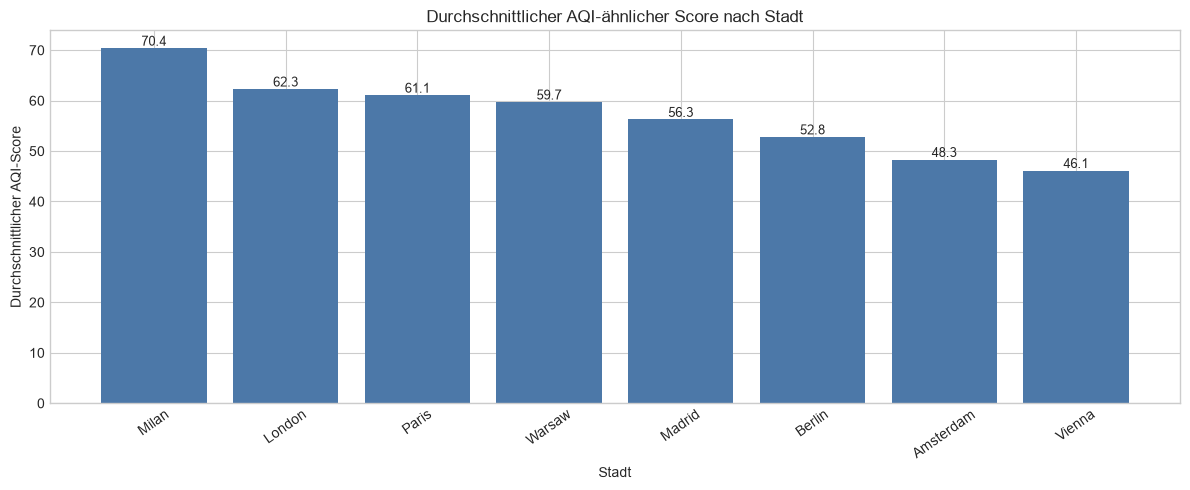

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(city_summary["city"], city_summary["avg_aqi_score"], color="#4c78a8")
ax.set_title("Durchschnittlicher AQI-ähnlicher Score nach Stadt")
ax.set_xlabel("Stadt")
ax.set_ylabel("Durchschnittlicher AQI-Score")
ax.tick_params(axis="x", rotation=35)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{height:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 2.3 Verteilung der Zielvariable

Für Machine Learning ist wichtig, ob die Zielklassen ungefähr verteilt sind oder ob eine Klasse dominiert. AirAlert sagt `Low`, `Medium` oder `High` vorher.

In [23]:
risk_distribution = (
    df["risk_level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .rename_axis("Risikoklasse")
    .reset_index(name="Anzahl")
)
risk_distribution["Anteil"] = (risk_distribution["Anzahl"] / len(df)).round(3)
risk_distribution

,Risikoklasse,Anzahl,Anteil
0,Low,103,0.179
1,Medium,412,0.715
2,High,61,0.106


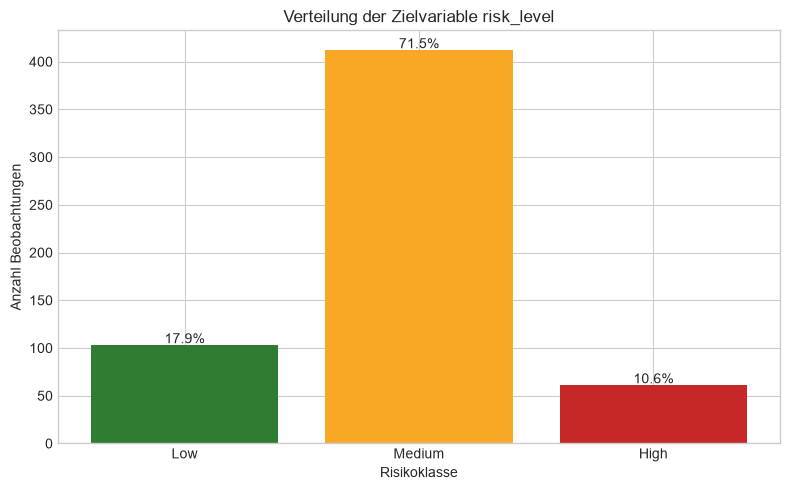

In [24]:
colors = {"Low": "#2e7d32", "Medium": "#f9a825", "High": "#c62828"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    risk_distribution["Risikoklasse"],
    risk_distribution["Anzahl"],
    color=[colors[label] for label in risk_distribution["Risikoklasse"]],
)
ax.set_title("Verteilung der Zielvariable risk_level")
ax.set_xlabel("Risikoklasse")
ax.set_ylabel("Anzahl Beobachtungen")

for i, row in risk_distribution.iterrows():
    ax.text(i, row["Anzahl"] + 2, f"{row['Anteil']:.1%}", ha="center")

plt.tight_layout()
plt.show()

### 2.4 Saisonale Muster: Monat, Schadstoffe und Wetter

Wie im Beispielprojekt werden zeitliche Muster betrachtet. Bei AirAlert ist die Jahreszeit wichtig, weil Wintermonate und Sommermonate unterschiedliche Schadstoffdynamiken haben können.

In [25]:
monthly_pattern = (
    df.groupby("month", as_index=False)
    .agg(
        avg_aqi_score=("aqi_score", "mean"),
        avg_pm25=("pm25", "mean"),
        avg_no2=("no2", "mean"),
        avg_o3=("o3", "mean"),
        avg_temperature=("temperature_c", "mean"),
        avg_wind=("wind_kmh", "mean"),
    )
)
monthly_pattern.round(2)

,month,avg_aqi_score,avg_pm25,avg_no2,avg_o3,avg_temperature,avg_wind
0,1,70.65,26.46,37.94,28.76,10.46,13.39
1,2,69.55,25.75,37.84,32.65,16.17,13.84
2,3,50.59,17.37,34.99,35.50,20.40,13.32
3,4,50.20,17.21,34.54,36.34,21.55,13.01
4,5,49.25,16.72,34.24,35.07,20.79,13.52
5,6,52.84,16.20,33.44,52.53,16.04,13.51
6,7,53.25,16.54,34.46,49.55,10.93,13.33
7,8,53.16,16.61,33.83,46.39,5.22,13.50
8,9,48.88,17.40,34.38,22.38,0.81,13.80
9,10,48.14,16.55,34.23,22.95,-0.30,14.14


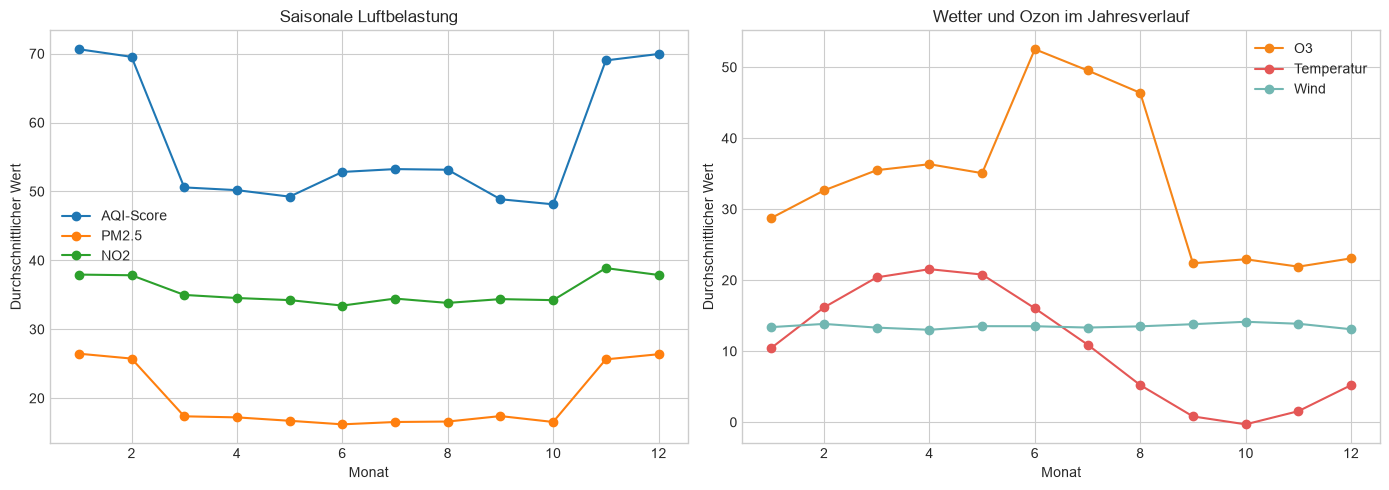

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly_pattern["month"], monthly_pattern["avg_aqi_score"], marker="o", label="AQI-Score")
axes[0].plot(monthly_pattern["month"], monthly_pattern["avg_pm25"], marker="o", label="PM2.5")
axes[0].plot(monthly_pattern["month"], monthly_pattern["avg_no2"], marker="o", label="NO2")
axes[0].set_title("Saisonale Luftbelastung")
axes[0].set_xlabel("Monat")
axes[0].set_ylabel("Durchschnittlicher Wert")
axes[0].legend()

axes[1].plot(monthly_pattern["month"], monthly_pattern["avg_o3"], marker="o", color="#f58518", label="O3")
axes[1].plot(monthly_pattern["month"], monthly_pattern["avg_temperature"], marker="o", color="#e45756", label="Temperatur")
axes[1].plot(monthly_pattern["month"], monthly_pattern["avg_wind"], marker="o", color="#72b7b2", label="Wind")
axes[1].set_title("Wetter und Ozon im Jahresverlauf")
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Durchschnittlicher Wert")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.5 Stadtprofile als Kontextdaten

Die Stadtprofile sind keine Zielvariable, sondern erklärende Kontextdaten. Sie helfen später dem Modell, strukturelle Unterschiede zwischen Städten zu lernen.

In [27]:
CITY_PROFILES

,city,country,latitude,longitude,population_m,traffic_index,green_space_index,industrial_index
0,Berlin,Germany,52.5200,13.4050,3.76,58,46,38
1,Paris,France,48.8566,2.3522,2.16,73,32,44
2,London,United Kingdom,51.5072,-0.1276,8.98,78,40,41
3,Madrid,Spain,40.4168,-3.7038,3.22,64,35,36
4,Milan,Italy,45.4642,9.1900,1.35,82,28,66
5,Warsaw,Poland,52.2297,21.0122,1.79,62,39,58
6,Amsterdam,Netherlands,52.3676,4.9041,0.92,49,44,33
7,Vienna,Austria,48.2082,16.3738,1.90,45,51,29


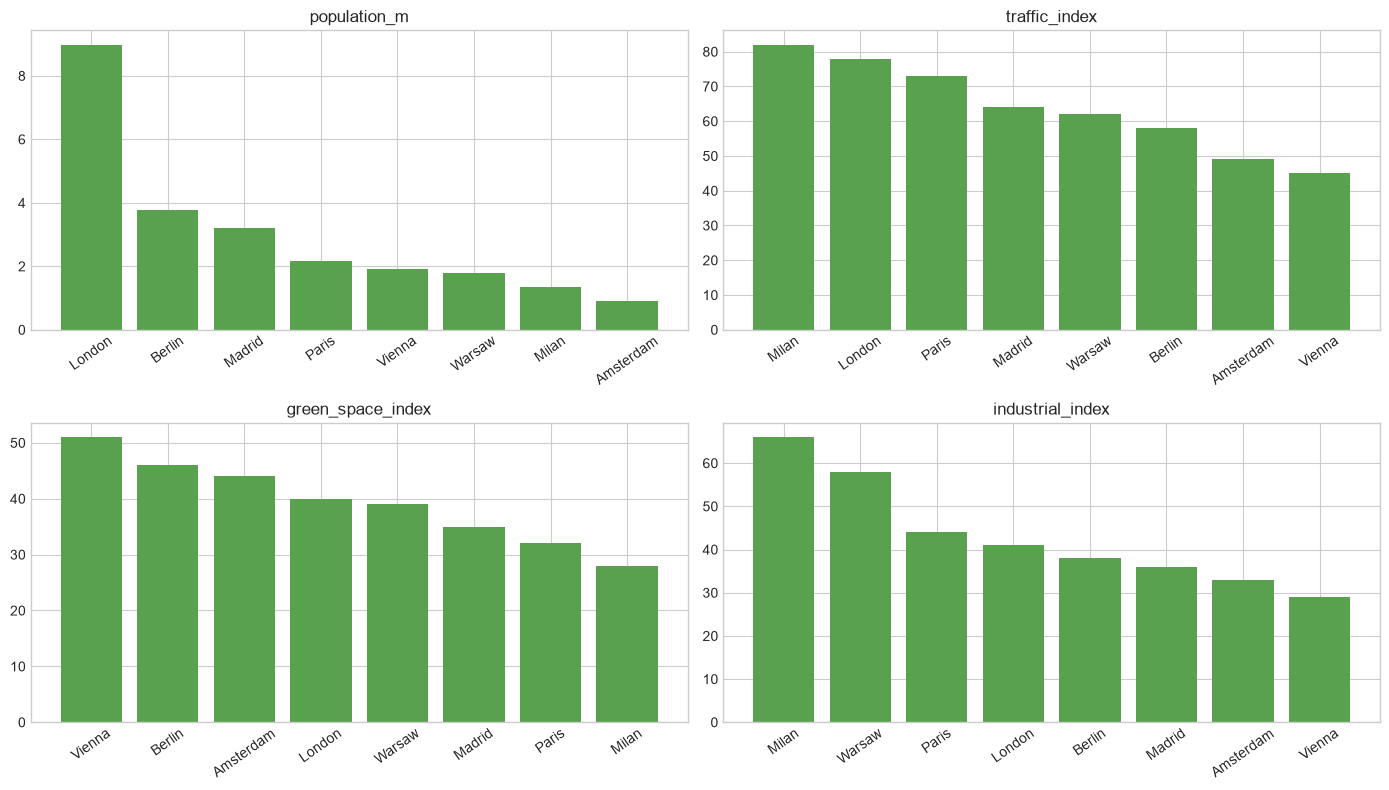

In [28]:
context_cols = ["population_m", "traffic_index", "green_space_index", "industrial_index"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, context_cols):
    ordered = CITY_PROFILES.sort_values(col, ascending=False)
    ax.bar(ordered["city"], ordered[col], color="#59a14f")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## Aufgabe 3: Die Detektivarbeit - Umgang mit fehlenden Daten

Im Beispielprojekt wird geprüft, ob Daten fehlen und ob diese Lücken fachlich erklärbar sind. Auch AirAlert muss diesen Schritt sauber dokumentieren.

In [29]:
missing_table = (
    df.isna()
    .sum()
    .rename_axis("Spalte")
    .reset_index(name="Fehlende Werte")
)
missing_table["Anteil"] = (missing_table["Fehlende Werte"] / len(df)).round(4)
missing_table

,Spalte,Fehlende Werte,Anteil
0,date,0,0.0
1,year,0,0.0
2,month,0,0.0
3,city,0,0.0
4,country,0,0.0
5,latitude,0,0.0
6,longitude,0,0.0
7,population_m,0,0.0
8,traffic_index,0,0.0
9,green_space_index,0,0.0


In [30]:
quality_summary = pd.DataFrame(
    {
        "Prüfung": [
            "Fehlende Werte insgesamt",
            "Duplikate",
            "Eindeutige Städte",
            "Eindeutige Risikoklassen",
            "Jahre im Datensatz",
            "Monate pro Stadt",
        ],
        "Ergebnis": [
            int(df.isna().sum().sum()),
            int(df.duplicated().sum()),
            int(df["city"].nunique()),
            int(df["risk_level"].nunique()),
            f"{df['year'].min()}-{df['year'].max()}",
            int(df.groupby("city")["month"].count().min()),
        ],
    }
)
quality_summary

,Prüfung,Ergebnis
0,Fehlende Werte insgesamt,0
1,Duplikate,0
2,Eindeutige Städte,8
3,Eindeutige Risikoklassen,3
4,Jahre im Datensatz,2020-2025
5,Monate pro Stadt,72


In [31]:
df.dtypes.reset_index().rename(columns={"index": "Spalte", 0: "Datentyp"})

,Spalte,Datentyp
0,date,datetime64[us]
1,year,int64
2,month,int64
3,city,str
4,country,str
5,latitude,float64
6,longitude,float64
7,population_m,float64
8,traffic_index,float64
9,green_space_index,float64


### Erkenntnisse zur Datenqualität

Die Daten sind für die App stabil:

- Es gibt keine fehlenden Werte.
- Es gibt keine Duplikate.
- Alle Städte haben denselben Zeitraum.
- Die Zielvariable ist vollständig vorhanden.

Der wichtigste methodische Hinweis ist nicht fehlende Datenqualität, sondern **Datenherkunft**: Die Daten sind deterministisch erzeugt und bilden eine kontrollierte Prototypebene ab. Das muss in Präsentation und App klar gesagt werden.

## Aufgabe 4: Alles auf einen vergleichbaren Maßstab bringen

Das Beispielprojekt nutzt Skalierung, weil CO2, Meeresspiegel und Rasterdaten sehr unterschiedliche Wertebereiche haben. AirAlert hat ebenfalls unterschiedliche Skalen:

- Einwohnerzahl in Millionen,
- Verkehrsindex von ca. 0 bis 100,
- Schadstoffe in Konzentrationswerten,
- Wetterwerte in Grad, Prozent und km/h.

Für den finalen Random-Forest-Classifier ist Skalierung nicht zwingend notwendig, weil Baumverfahren nicht wie lineare Modelle auf vergleichbare Skalen angewiesen sind. Trotzdem ist die Analyse der Skalen in der U-Phase wichtig, weil sie erklärt, warum spätere Modelle unterschiedlich vorbereitet werden.

In [32]:
numeric_features = [
    "population_m",
    "traffic_index",
    "green_space_index",
    "industrial_index",
    "temperature_c",
    "humidity_pct",
    "wind_kmh",
    "pm25",
    "pm10",
    "no2",
    "o3",
]

scale_overview = df[numeric_features].agg(["min", "mean", "max"]).T.round(2)
scale_overview

,min,mean,max
population_m,0.92,3.01,8.98
traffic_index,45.00,63.88,82.00
green_space_index,28.00,39.38,51.00
industrial_index,29.00,43.12,66.00
temperature_c,-4.00,10.74,26.10
humidity_pct,41.90,64.32,88.50
wind_kmh,4.80,13.53,22.10
pm25,5.90,19.90,39.20
pm10,12.00,32.72,54.60
no2,16.40,35.55,59.20


In [33]:
sample_numeric = df[numeric_features].copy()

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(sample_numeric),
    columns=numeric_features,
)

minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(sample_numeric),
    columns=numeric_features,
)

comparison_scaling = pd.DataFrame(
    {
        "Original min": sample_numeric.min(),
        "Original max": sample_numeric.max(),
        "StandardScaler mean": standard_scaled.mean().round(3),
        "StandardScaler std": standard_scaled.std().round(3),
        "MinMax min": minmax_scaled.min().round(3),
        "MinMax max": minmax_scaled.max().round(3),
    }
)
comparison_scaling

,Original min,Original max,StandardScaler mean,StandardScaler std,MinMax min,MinMax max
population_m,0.92,8.98,0.0,1.001,0.0,1.0
traffic_index,45.00,82.00,0.0,1.001,0.0,1.0
green_space_index,28.00,51.00,-0.0,1.001,0.0,1.0
industrial_index,29.00,66.00,0.0,1.001,0.0,1.0
temperature_c,-4.00,26.10,0.0,1.001,0.0,1.0
humidity_pct,41.90,88.50,-0.0,1.001,0.0,1.0
wind_kmh,4.80,22.10,0.0,1.001,0.0,1.0
pm25,5.90,39.20,-0.0,1.001,0.0,1.0
pm10,12.00,54.60,-0.0,1.001,0.0,1.0
no2,16.40,59.20,0.0,1.001,0.0,1.0


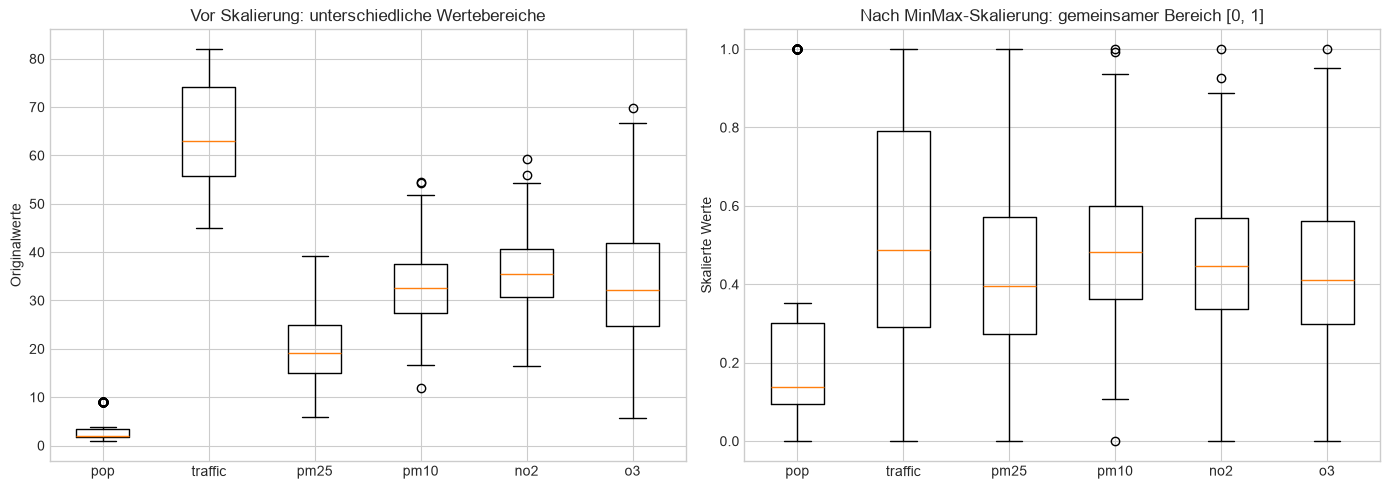

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(sample_numeric[["population_m", "traffic_index", "pm25", "pm10", "no2", "o3"]], tick_labels=["pop", "traffic", "pm25", "pm10", "no2", "o3"])
axes[0].set_title("Vor Skalierung: unterschiedliche Wertebereiche")
axes[0].set_ylabel("Originalwerte")

axes[1].boxplot(minmax_scaled[["population_m", "traffic_index", "pm25", "pm10", "no2", "o3"]], tick_labels=["pop", "traffic", "pm25", "pm10", "no2", "o3"])
axes[1].set_title("Nach MinMax-Skalierung: gemeinsamer Bereich [0, 1]")
axes[1].set_ylabel("Skalierte Werte")

plt.tight_layout()
plt.show()

### 4.1 Auswirkungen auf die Machine-Learning-Algorithmen

Die Skalierung hat je nach Modell unterschiedliche Bedeutung:

- **Logistische Regression:** Skalierung ist sinnvoll, weil lineare Modelle empfindlich auf unterschiedliche Wertebereiche reagieren.
- **Decision Tree / Random Forest:** Skalierung ist nicht zwingend notwendig, weil Splits nach Schwellenwerten funktionieren.
- **Gradient Boosting:** Skalierung ist meistens nicht zwingend notwendig, kann aber bei bestimmten Implementierungen hilfreich sein.

Für AirAlert bedeutet das:

- In der A-Phase darf Logistic Regression als skalierte Baseline verwendet werden.
- Der finale Random Forest kann numerische Features unverändert verwenden.
- `city` muss unabhängig davon mit One-Hot-Encoding umgewandelt werden.

## Aufgabe 5: Zusammenfassung und Interpretation im Projektkontext

Die U-Phase hat die datentechnische Grundlage für AirAlert geschaffen. Die drei Datenebenen ergeben gemeinsam eine sinnvolle Struktur für ein Klassifikationsmodell.

### 1. Zusammenfassung der Erkenntnisse

- **Datensätze:** AirAlert nutzt Luftqualitätsdaten, Wetterdaten und Stadtstruktur-Daten.
- **Muster:** Städte mit höherem Verkehrs- und Industrieindex zeigen tendenziell höhere Belastungswerte.
- **Saison:** Monatliche Muster sind sichtbar, besonders bei PM2.5, NO2, O3 und Temperatur.
- **Datenqualität:** Es gibt keine fehlenden Werte und keine Duplikate.
- **Preprocessing:** Stadtname muss codiert werden; numerische Features können für Random Forest unverändert bleiben.
- **Zielvariable:** `risk_level` ist vollständig und in drei verständliche Klassen aufgeteilt.

### 2. Reflexion und Interpretation

**Welche Merkmale sind für die App am wichtigsten?**

Die wichtigsten Merkmalsgruppen sind Schadstoffwerte (`pm25`, `pm10`, `no2`, `o3`), Wetterbedingungen (`temperature_c`, `humidity_pct`, `wind_kmh`) und Stadtstruktur (`traffic_index`, `green_space_index`, `industrial_index`, `population_m`). Genau diese Kombination macht AirAlert zu einem mehrschichtigen Umwelt-ML-Projekt.

**Welche Herausforderung gibt es?**

Die größte methodische Herausforderung ist, dass die aktuelle Version mit deterministischen Demodaten arbeitet. Das ist technisch stabil und präsentationssicher, aber keine offizielle Live-Messung. Diese Grenze muss transparent erklärt werden.

**Welche Daten dürfen nicht als Feature verwendet werden?**

`aqi_score` darf in der U-Phase erklärt werden, sollte aber in der A-Phase nicht als Eingabefeature verwendet werden. Da `risk_level` direkt aus `aqi_score` abgeleitet wird, wäre das sonst Target Leakage.

**Wie werden diese Daten in der App genutzt?**

Die Streamlit-App nutzt die Daten, um:

1. den Trainingsdatensatz zu erzeugen,
2. einen Random-Forest-Classifier zu trainieren,
3. Nutzer-Szenarien über Sidebar-Slider aufzunehmen,
4. eine Risikoklasse vorherzusagen,
5. Wahrscheinlichkeiten, Trends und Feature Importance sichtbar zu machen.

**Entscheidung für die nächste Phase:**

```text
Go zur A-Phase: Ja.
```

Die Daten sind vollständig, strukturiert und passend für ein Klassifikationsmodell.